<a href="https://colab.research.google.com/github/MANOGNA-537/NASSCOM_WEEK1/blob/main/U6_Probability_Statistics_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)


Setup complete. NumPy 2.1.3


In [ ]:
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')


P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [ ]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')



P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [ ]:
import numpy as np

flips = np.random.randint(0, 2, size=(100_000, 2)) # 100k pairs of flips
heads = flips.sum(axis=1) # number of heads in each pair: 0, 1 or 2

# 1. P(both heads) -> heads == 2
p_both_heads = np.mean(heads == 2)
print(f"Estimated P(both heads): {p_both_heads:.4f}")

# 2. P(at least one head) -> heads >= 1
p_at_least_one = np.mean(heads >= 1)
print(f"Estimated P(at least one head): {p_at_least_one:.4f}")

# 3. Do P(0) + P(1) + P(2) sum to 1?
p_0 = np.mean(heads == 0)
p_1 = np.mean(heads == 1)
p_2 = np.mean(heads == 2)
total_sum = p_0 + p_1 + p_2

print(f"P(0 heads): {p_0:.4f}")
print(f"P(1 head):  {p_1:.4f}")
print(f"P(2 heads): {p_2:.4f}")
print(f"Total sum:  {total_sum}")



Estimated P(both heads): 0.2520
Estimated P(at least one head): 0.7493
P(0 heads): 0.2507
P(1 head):  0.4973
P(2 heads): 0.2520
Total sum:  1.0


In [ ]:

rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')



P(6 | even) ~ 0.332  (true 1/3)


In [ ]:
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))


P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


In [ ]:
import numpy as np

# Generate 100,000 random dice rolls (1 to 6)
rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4) -> condition on rolls < 4, then check odd
rolls_less_than_4 = rolls[rolls < 4]
p_odd_given_less_than_4 = np.mean(rolls_less_than_4 % 2 != 0)

# 2. P(roll < 4)
p_less_than_4 = np.mean(rolls < 4)

# 3. Compare P(odd | <4) with P(odd) overall — independent?
p_odd_overall = np.mean(rolls % 2 != 0)

# Print the simulation results
print(f"1. Estimated P(roll is odd | roll < 4) = {p_odd_given_less_than_4:.4f}")
print(f"2. Estimated P(roll < 4)               = {p_less_than_4:.4f}")
print(f"3. Estimated P(roll is odd) overall    = {p_odd_overall:.4f}")

# Check for independence
are_independent = np.isclose(p_odd_given_less_than_4, p_odd_overall, atol=1e-2)
print(f"Are the events independent? {are_independent}")


1. Estimated P(roll is odd | roll < 4) = 0.6680
2. Estimated P(roll < 4)               = 0.4990
3. Estimated P(roll is odd) overall    = 0.5025
Are the events independent? False


In [ ]:
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')



P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [ ]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))


Simulated P(sick | positive) = 0.503


In [ ]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham = 0.05

# 2. P('free') via total probability
p_ham = 1.0 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print(f"P('free') = {p_free:.2f}") # Output: 0.16

# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print(f"P(spam | 'free') = {p_spam_given_free:.2f}") # Output: 0.75


P('free') = 0.16
P(spam | 'free') = 0.75


In [ ]:
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')



Bernoulli(0.3) mean ~ 0.288 (true 0.3)
Poisson(4) mean ~ 3.993 (true 4)


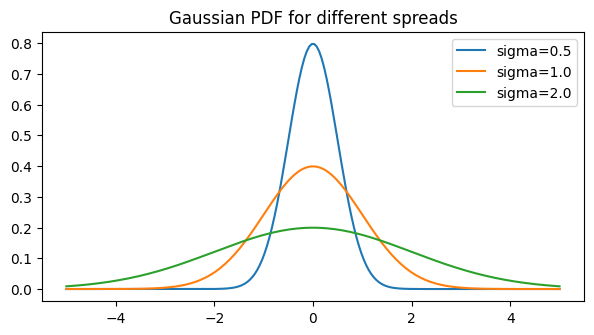

In [ ]:
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()



<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:60: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1739/1843092304.py:32: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f"Poisson Distribution ($\mu={mu}$)\nSample Mean: {sample_mean:.4f}")
/tmp/ipykernel_1739/1843092304.py:57: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, pdf1, label=f'$\sigma = {sigma1}$ (Narrower)', color='darkorange', linewidth=2.5)
/tmp/ipykernel_1739/1843092304.py:58: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, pdf2, label=f'$\sigma = {sigma2}$ (Wider)', color='forestgreen', linewidth=2.5)
/tmp/ipykernel_1739/1843092304.py:60: SyntaxWarning: invalid escape sequen

Sample Mean: 2.0064


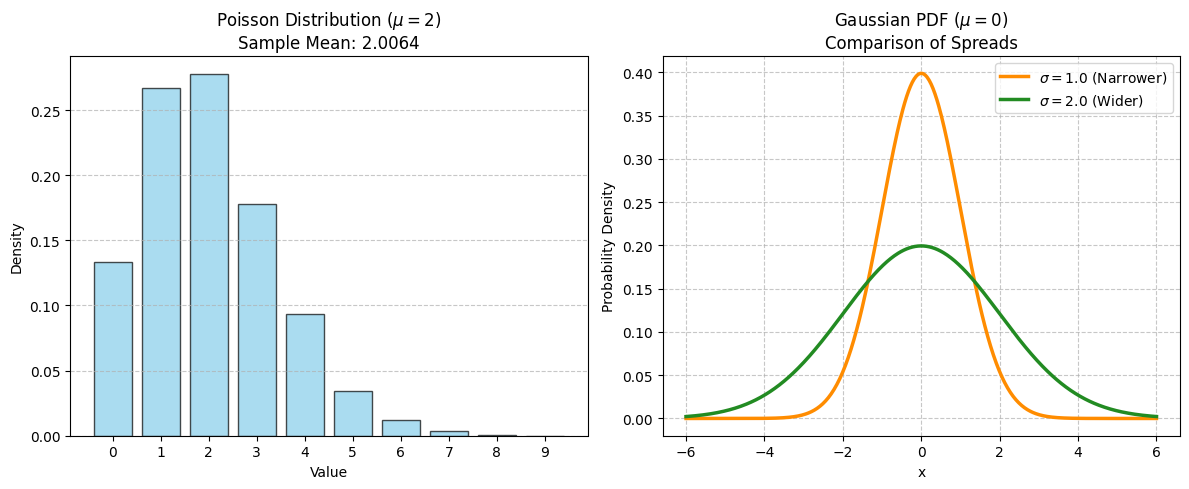

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Set a random seed for reproducible outputs
np.random.seed(42)

# =====================================================================
# 1. Poisson(mu=2) samples + mean
# =====================================================================
mu = 2
num_samples = 10000

# Draw 10,000 samples from a Poisson distribution
samples = np.random.poisson(lam=mu, size=num_samples)

# Calculate and print the sample mean
sample_mean = np.mean(samples)
print(f"Sample Mean: {sample_mean}")


# =====================================================================
# 2. Histogram of the samples
# =====================================================================
plt.figure(figsize=(12, 5))

# Subplot 1: Poisson Histogram
plt.subplot(1, 2, 1)
# Since Poisson is a discrete distribution, we align bins to integer values
bins = np.arange(0, np.max(samples) + 1.5) - 0.5
plt.hist(samples, bins=bins, density=True, rwidth=0.8, color='skyblue', edgecolor='black', alpha=0.7)
plt.title(f"Poisson Distribution ($\mu={mu}$)\nSample Mean: {sample_mean:.4f}")
plt.xlabel("Value")
plt.ylabel("Density")
plt.xticks(range(0, np.max(samples) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)


# =====================================================================
# 3. Gaussian PDF for two sigmas on one plot
# =====================================================================
plt.subplot(1, 2, 2)

# Define parameters
mu_gauss = 0
sigma1 = 1.0
sigma2 = 2.0

# Generate x values for plotting the continuous PDF
x = np.linspace(-6, 6, 500)

# Calculate Gaussian PDF curves
pdf1 = stats.norm.pdf(x, loc=mu_gauss, scale=sigma1)
pdf2 = stats.norm.pdf(x, loc=mu_gauss, scale=sigma2)

# Plot both lines on the same chart
plt.plot(x, pdf1, label=f'$\sigma = {sigma1}$ (Narrower)', color='darkorange', linewidth=2.5)
plt.plot(x, pdf2, label=f'$\sigma = {sigma2}$ (Wider)', color='forestgreen', linewidth=2.5)

plt.title("Gaussian PDF ($\mu=0$)\nComparison of Spreads")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(linestyle='--', alpha=0.7)

# Adjust layout and show the charts
plt.tight_layout()
plt.show()
